<a href="https://colab.research.google.com/github/kir0ul/neural-processes/blob/master/attentive_neural_process_jax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Copyright 2019 Google LLC

Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at

https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.

# (Attentive) Neural Processes for 1D regression — JAX port

Regression is usually cast as modelling the distribution of output **y** given input **x** via a deterministic function, such as a neural network, taking **x** as input. In this setting, the model is trained on a dataset of input-output pairs, and predictions of the outputs are independent of each other given the inputs. An alternative approach to regression involves using the training data to compute a distribution over functions that map inputs to outputs, and using draws from that distribution to make predictions on test inputs. This approach allows for reasoning about multiple functions consistent with the data, and can capture the co-variability in outputs given inputs. In the Bayesian machine learning literature, non-parametric models such as Gaussian Processes (GPs) are popular choices of this approach.

[Neural Processes](https://arxiv.org/abs/1807.01622) (NPs) also approach regression by modelling a distribution over regression functions. Each function models the distribution of the output given an input, conditioning on some observed input-output pairs, which we call the context. Modelling this distribution over functions was made possible by incorporating a latent variable to the [Conditional Neural Process](https://arxiv.org/abs/1807.01613) (CNP).

However NPs suffer from underfitting, giving inaccurate predictions at the inputs of the observed data they condition on. Hence [Attentive Neural Processes](https://arxiv.org/abs/1901.05761) (ANPs) were introduced, addressing this issue by incorporating attention into NPs. We share the implementation of ANPs (and NPs, which is a special case of ANP with uniform attention) for a 1D regression task where (A)NPs are trained on random 1D functions.

**About this version:** this notebook is a [JAX](https://github.com/jax-ml/jax) + [Flax](https://github.com/google/flax) + [Optax](https://github.com/google-deepmind/optax) port of the original TensorFlow 1 notebook. The model, data generator and training loop have all been rewritten to be functionally pure and to use explicit `PRNGKey`s instead of a stateful `tf.Session`/graph, but the maths and the overall structure of the code closely follow the original so the two versions can be compared side by side. See the note in the "Training the (A)NP" section below for one JAX-specific caveat around dynamic shapes.

## Imports

In [1]:
try:
  import jax
except ImportError:
  %pip install -q jax jaxlib
  import jax

# Some pre-provisioned environments (e.g. Colab) ship a `flax`/`optax` build
# that predates the currently installed `jax` release. Because Flax only
# touches JAX-internal tracing APIs once you actually call a Module (not at
# import time), a stale `flax` can `import` successfully and then fail much
# later with something like:
#   AttributeError: jax.core.get_opaque_trace_state was deprecated ... removed
# So rather than only installing flax/optax when the import fails, always
# upgrade them to versions compatible with the already-installed jax
# (jax/jaxlib themselves are left alone so any accelerator-specific build
# already installed - e.g. for a Colab GPU/TPU runtime - is preserved).
%pip install -q -U flax optax
import flax
import optax

# The original notebook casts the GP kernel to float64 before the Cholesky
# decomposition for numerical stability - enable x64 in JAX to match.
jax.config.update("jax_enable_x64", True)

import collections
from typing import Optional, Sequence

import jax.numpy as jnp
import flax.linen as nn
import numpy as np
import matplotlib.pyplot as plt

## Data generator
Instead of training using observations from a single function (as in classic regression tasks), we would like to train on a dataset that comes from multiple functions with shared characteristics. Hence for training, we use data that comes from a Gaussian Process (GP) with randomly varying kernel parameters.  At each training iteration, we sample a batch of random kernel parameters, and for each parameter setting we sample a curve (a realisation) from the corresponding GP. We select random points on each curve to be the targets and a subset to be the contexts for optimising the training loss. The data generation is almost the same as for the [implementation of CNPs](https://github.com/deepmind/conditional-neural-process/blob/master/conditional_neural_process.ipynb), but with kernel parameters varying randomly at each iteration.

JAX arrays are immutable and JAX's random number generation is purely functional, so instead of relying on TensorFlow's stateful `tf.random_uniform` ops, `GPCurvesReader.generate_curves` below takes an explicit `PRNGKey` and returns both the sampled batch and a fresh key to use next time. The number of context/target points (`num_context`, `num_target`) still has to be resolved to concrete Python integers (rather than being left as JAX-traced values) since JAX requires array shapes to be static.

In [2]:
# The (A)NP takes as input a `NPRegressionDescription` namedtuple with fields:
#   `query`: a tuple containing ((context_x, context_y), target_x)
#   `target_y`: a tensor containing the ground truth for the targets to be
#     predicted
#   `num_total_points`: A scalar that describes the total number of
#     datapoints used (context + target)
#   `num_context_points`: A scalar that describes the number of datapoints
#     used as context
# The GPCurvesReader returns the newly sampled data in this format each time
# `generate_curves` is called.

NPRegressionDescription = collections.namedtuple(
    "NPRegressionDescription",
    ("query", "target_y", "num_total_points", "num_context_points"))


class GPCurvesReader(object):
  """Generates curves using a Gaussian Process (GP).

  Supports vector inputs (x) and vector outputs (y). Kernel is
  mean-squared exponential, using the x-value l2 coordinate distance scaled by
  some factor chosen randomly in a range. Outputs are independent gaussian
  processes.
  """

  def __init__(self,
               batch_size,
               max_num_context,
               x_size=1,
               y_size=1,
               l1_scale=0.6,
               sigma_scale=1.0,
               random_kernel_parameters=True,
               testing=False):
    """Creates a regression dataset of functions sampled from a GP.

    Args:
      batch_size: An integer.
      max_num_context: The max number of observations in the context.
      x_size: Integer >= 1 for length of "x values" vector.
      y_size: Integer >= 1 for length of "y values" vector.
      l1_scale: Float; typical scale for kernel distance function.
      sigma_scale: Float; typical scale for variance.
      random_kernel_parameters: If `True`, the kernel parameters (l1 and sigma)
          will be sampled uniformly within [0.1, l1_scale] and [0.1, sigma_scale].
      testing: Boolean that indicates whether we are testing. If so there are
          more targets for visualization.
    """
    self._batch_size = batch_size
    self._max_num_context = max_num_context
    self._x_size = x_size
    self._y_size = y_size
    self._l1_scale = l1_scale
    self._sigma_scale = sigma_scale
    self._random_kernel_parameters = random_kernel_parameters
    self._testing = testing

  def _gaussian_kernel(self, xdata, l1, sigma_f, sigma_noise=2e-2):
    """Applies the Gaussian kernel to generate curve data.

    Args:
      xdata: Array of shape [B, num_total_points, x_size] with
          the values of the x-axis data.
      l1: Array of shape [B, y_size, x_size], the scale
          parameter of the Gaussian kernel.
      sigma_f: Array of shape [B, y_size], the magnitude
          of the std.
      sigma_noise: Float, std of the noise that we add for stability.

    Returns:
      The kernel, a float array of shape
      [B, y_size, num_total_points, num_total_points].
    """
    num_total_points = xdata.shape[1]

    # Expand and take the difference
    xdata1 = xdata[:, None, :, :]  # [B, 1, num_total_points, x_size]
    xdata2 = xdata[:, :, None, :]  # [B, num_total_points, 1, x_size]
    diff = xdata1 - xdata2  # [B, num_total_points, num_total_points, x_size]

    # [B, y_size, num_total_points, num_total_points, x_size]
    norm = jnp.square(diff[:, None, :, :, :] / l1[:, :, None, None, :])

    norm = jnp.sum(
        norm, -1)  # [B, data_size, num_total_points, num_total_points]

    # [B, y_size, num_total_points, num_total_points]
    kernel = jnp.square(sigma_f)[:, :, None, None] * jnp.exp(-0.5 * norm)

    # Add some noise to the diagonal to make the cholesky work.
    kernel += (sigma_noise**2) * jnp.eye(num_total_points)

    return kernel

  def generate_curves(self, rng):
    """Builds a batch of data.

    Generated functions are `float32` with x values between -2 and 2.

    Args:
      rng: A JAX `PRNGKey`.

    Returns:
      A tuple `(NPRegressionDescription, rng)`, where `rng` is a fresh key
      that should be used for the next call (JAX keys should never be reused).
    """
    rng, key = jax.random.split(rng)
    num_context = int(jax.random.randint(
        key, (), minval=3, maxval=self._max_num_context))

    # If we are testing we want to have more targets and have them evenly
    # distributed in order to plot the function.
    if self._testing:
      num_target = 400
      num_total_points = num_target
      x_values = jnp.tile(
          jnp.arange(-2., 2., 1. / 100, dtype=jnp.float32)[None, :],
          [self._batch_size, 1])
      x_values = x_values[..., None]
    # During training the number of target points and their x-positions are
    # selected at random
    else:
      rng, key = jax.random.split(rng)
      num_target = int(jax.random.randint(
          key, (), minval=0, maxval=self._max_num_context - num_context))
      num_total_points = num_context + num_target
      rng, key = jax.random.split(rng)
      x_values = jax.random.uniform(
          key, (self._batch_size, num_total_points, self._x_size),
          minval=-2, maxval=2)

    # Set kernel parameters
    # Either choose a set of random parameters for the mini-batch
    if self._random_kernel_parameters:
      rng, l1_key, sigma_key = jax.random.split(rng, 3)
      l1 = jax.random.uniform(
          l1_key, (self._batch_size, self._y_size, self._x_size),
          minval=0.1, maxval=self._l1_scale)
      sigma_f = jax.random.uniform(
          sigma_key, (self._batch_size, self._y_size),
          minval=0.1, maxval=self._sigma_scale)
    # Or use the same fixed parameters for all mini-batches
    else:
      l1 = jnp.ones((self._batch_size, self._y_size,
                     self._x_size)) * self._l1_scale
      sigma_f = jnp.ones((self._batch_size, self._y_size)) * self._sigma_scale

    # Pass the x_values through the Gaussian kernel
    # [batch_size, y_size, num_total_points, num_total_points]
    kernel = self._gaussian_kernel(x_values, l1, sigma_f)

    # Calculate Cholesky, using double precision for better stability:
    cholesky = jnp.linalg.cholesky(kernel.astype(jnp.float64)).astype(jnp.float32)

    # Sample a curve
    # [batch_size, y_size, num_total_points, 1]
    rng, key = jax.random.split(rng)
    y_values = jnp.matmul(
        cholesky,
        jax.random.normal(
            key, (self._batch_size, self._y_size, num_total_points, 1)))

    # [batch_size, num_total_points, y_size]
    y_values = jnp.transpose(jnp.squeeze(y_values, axis=3), [0, 2, 1])

    if self._testing:
      # Select the targets
      target_x = x_values
      target_y = y_values

      # Select the observations
      rng, key = jax.random.split(rng)
      idx = jax.random.permutation(key, num_target)
      context_x = x_values[:, idx[:num_context], :]
      context_y = y_values[:, idx[:num_context], :]

    else:
      # Select the targets which will consist of the context points as well as
      # some new target points
      target_x = x_values[:, :num_target + num_context, :]
      target_y = y_values[:, :num_target + num_context, :]

      # Select the observations
      context_x = x_values[:, :num_context, :]
      context_y = y_values[:, :num_context, :]

    query = ((context_x, context_y), target_x)

    return NPRegressionDescription(
        query=query,
        target_y=target_y,
        num_total_points=target_x.shape[1],
        num_context_points=num_context), rng

## Attentive Neural Processes: a short introduction

Here below are the model diagrams for the **NP** (left) and **ANP** (right).

![](https://i.ibb.co/Js1B7RB/model-figure-new-1-page-001.jpg)

In the NP, the **context points** $(x_C,y_C)=(x_i, y_i)_{i \in C}$ are passed through the encoder that consists of two paths, a **deterministic path** and and a **latent path**.

In the **deterministic path**, each context pair $(x_i,y_i)$ is passed through an MLP (shared parameters across the contexts) to produce representation $r_i$. These are aggregated by taking the mean to produce the deterministic code $r_C$.

In the **latent path**, a code $s_C$ is computed in a similar manner from the representations $s_i$, and is used to parameterise the distribution of the latent variable $z$, giving the latent distribution $q(z|s_C)$.

In the decoder, the $r_C$ and $z$ are concatenated alongside $x_*$ and passed through an MLP to produce the parameters of the distribution $p(y_*|x_*,r_C,z)$.

The motivation for having a global latent is to model different realisations of the data generating stochastic process - each sample of $z$ would correspond to one realisation of the stochastic process. One can define the model using just the deterministic path, just the latent path, or both.

One problem of the NP is that the **mean-aggregation step in the encoder acts as a bottleneck**: since taking the mean across context representations gives the same weight to each context point, it is difficult for the decoder to learn which context points provide relevant information for a given target prediction.

This is addressed by ANPs, where the mean-aggregation is replaced by a **cross-attention mechanism** - the target query $x_*$ attends to the key-value pairs $(x_i,r_i)_{i \in C}$ and assigns weights $w_i$ to each pair to form a query-specific representation $r_*=\sum_i w_i r_i$. This is precisely where the model allows each query to attend more closely to the context points that it deems relevant for the prediction. Note that if we use uniform attention (all $w_i$ equal), then we revert to the NP.

Another change is the **self-attention mechanism** that replaces the MLPs in the encoder, used in order to model interactions between the context points. However for the 1D regression task here, we do not use self-attention and resort to the MLP setting as it is shown to be sufficient, and just use cross-attention.

Learning for both the NP and ANP is done by optimising the ELBO to the log predictive likelihood:

$$\log p(y_T|x_T,x_C,y_C)  \geq
\mathbb{E}_{q(z|s_T)}  [\log p(y_T|x_T,r_C,z)] - KL ( q(z|s_T) \Vert q(z|s_C) )$$
where $C$ represents contexts and $T$ represents targets.

**Implementation note:** the model is implemented with [Flax linen](https://flax.readthedocs.io/) modules. Because a `flax.linen.Module` shares its parameters across every call made to the *same submodule instance*, weight sharing (e.g. re-using the same MLP for the prior and the posterior in the latent encoder, or for `k` and `q` in the attention module) falls out automatically as long as the submodule is only constructed once (in `setup()`) and then called multiple times - this replaces TensorFlow's `tf.variable_scope(..., reuse=tf.AUTO_REUSE)` pattern. `flax.linen.Dense` also operates on the last axis of an array regardless of how many leading (batch) dimensions it has, which means the manual reshape-to-2D-and-back dance that `batch_mlp` did in TF1 is no longer necessary.

In [3]:
# utility module
class BatchMLP(nn.Module):
  """Apply an MLP to the final axis of an array.

  This is the JAX/Flax equivalent of the original `batch_mlp` helper.
  `nn.Dense` already broadcasts over any number of leading batch
  dimensions and applies the same weights to every one of them, so
  (unlike the TF1 version) there is no need to manually reshape the
  input to 2D and back - and weight sharing across multiple calls
  comes for free simply by re-using the same `BatchMLP` instance.

  Args:
    output_sizes: An iterable containing the output sizes of the MLP.
  """
  output_sizes: Sequence[int]

  @nn.compact
  def __call__(self, x):
    """Args: x: input array of shape [B, n, d_in].

    Returns: array of shape [B, n, d_out] where d_out=output_sizes[-1].
    """
    for i, size in enumerate(self.output_sizes[:-1]):
      x = nn.relu(nn.Dense(size, name=f"layer_{i}")(x))
    # Last layer without a ReLu
    x = nn.Dense(self.output_sizes[-1], name=f"layer_{len(self.output_sizes) - 1}")(x)
    return x

## Encoder: Deterministic Path

The encoder in the deterministic path is shared between all context pairs and consists of an MLP and an attention module. Each context $x_i$ and $y_i$ are concatenated and passed through the MLP (with relu non-linearities) to output a representation $r_i$. These $(r_i)_{i \in C}$ and $x_i$ are fed into the cross-attention module, along with query $x_*$ to output a query-specific representation $r_*$. The MLP architecture is given by the `output_sizes` argument, a list of hidden layer sizes, and the `attention` argument which is the cross-attention module defined later on.

In [4]:
class DeterministicEncoder(nn.Module):
  """The Deterministic Encoder.

  Args:
    output_sizes: An iterable containing the output sizes of the encoding MLP.
    attention: The attention module.
  """
  output_sizes: Sequence[int]
  attention: "Attention"

  @nn.compact
  def __call__(self, context_x, context_y, target_x):
    """Encodes the inputs into one representation.

    Args:
      context_x: Array of shape [B,observations,d_x]. For this 1D regression
          task this corresponds to the x-values.
      context_y: Array of shape [B,observations,d_y]. For this 1D regression
          task this corresponds to the y-values.
      target_x: Array of shape [B,target_observations,d_x].
          For this 1D regression task this corresponds to the x-values.

    Returns:
      The encoded representation. Array of shape [B,target_observations,d]
    """
    # Concatenate x and y along the filter axes
    encoder_input = jnp.concatenate([context_x, context_y], axis=-1)

    # Pass final axis through MLP
    hidden = BatchMLP(self.output_sizes)(encoder_input)

    # Apply attention
    hidden = self.attention(context_x, target_x, hidden)

    return hidden

## Encoder: Latent Path

The encoder in the latent path is again shared by all context pairs and consists of an MLP.  After the MLP (with relu non-linearities) is applied the resulting representation is aggregated by taking the mean across the contexts and a further MLP is applied to compute the mean and variance of the Gaussian $q(z|s_C)$. Again the initial MLP's architecture is given by the `output_sizes` argument, and the `num_latent` argument sets the latent dimensionality.

In [5]:
class LatentEncoder(nn.Module):
  """The Latent Encoder.

  Args:
    output_sizes: An iterable containing the output sizes of the encoding MLP.
    num_latents: The latent dimensionality.
  """
  output_sizes: Sequence[int]
  num_latents: int

  @nn.compact
  def __call__(self, x, y):
    """Encodes the inputs into the parameters of a diagonal Gaussian.

    Args:
      x: Array of shape [B,observations,d_x]. For this 1D regression
          task this corresponds to the x-values.
      y: Array of shape [B,observations,d_y]. For this 1D regression
          task this corresponds to the y-values.

    Returns:
      A `(mu, sigma)` pair of arrays of shape [B, num_latents] giving the
      mean and standard deviation of a diagonal Normal distribution over
      the latent variable. (TF's `tf.contrib.distributions.Normal` has no
      direct JAX equivalent that ships by default, so instead of returning
      a distribution object we return its parameters directly and provide
      small `normal_sample`/`normal_kl` helper functions below.)
    """
    # Concatenate x and y along the filter axes
    encoder_input = jnp.concatenate([x, y], axis=-1)

    # Pass final axis through MLP
    hidden = BatchMLP(self.output_sizes)(encoder_input)

    # Aggregator: take the mean over all points
    hidden = jnp.mean(hidden, axis=1)

    # Have further MLP layers that map to the parameters of the Gaussian latent
    # First apply intermediate relu layer
    hidden = nn.relu(nn.Dense(
        (self.output_sizes[-1] + self.num_latents) // 2,
        name="penultimate_layer")(hidden))
    # Then apply further linear layers to output latent mu and log sigma
    mu = nn.Dense(self.num_latents, name="mean_layer")(hidden)
    log_sigma = nn.Dense(self.num_latents, name="std_layer")(hidden)

    # Compute sigma
    sigma = 0.1 + 0.9 * nn.sigmoid(log_sigma)

    return mu, sigma


def normal_sample(rng, mu, sigma):
  """Reparameterised sample from a diagonal Normal(mu, sigma)."""
  return mu + sigma * jax.random.normal(rng, mu.shape)


def normal_kl(mu1, sigma1, mu2, sigma2):
  """Elementwise closed-form KL(N(mu1, sigma1) || N(mu2, sigma2))."""
  return (jnp.log(sigma2 / sigma1)
          + (jnp.square(sigma1) + jnp.square(mu1 - mu2)) / (2 * jnp.square(sigma2))
          - 0.5)

## Decoder

The context representation (either $z$ or $z$ and $r_C$ concatenated) and the target inputs $x_T$ are fed into the decoder. First they are concatenated and passed through an MLP, whose architecture is given by the `output_sizes` argument. The MLP outputs the mean and variance of the Gaussian $p(y_T|x_T,r_C,z)$.

In [6]:
class Decoder(nn.Module):
  """The Decoder.

  Args:
    output_sizes: An iterable containing the sizes of the decoder MLP layers.
  """
  output_sizes: Sequence[int]

  @nn.compact
  def __call__(self, representation, target_x):
    """Decodes the individual targets.

    Args:
      representation: The representation of the context for target predictions.
          Array of shape [B,target_observations,?].
      target_x: The x locations for the target query.
          Array of shape [B,target_observations,d_x].

    Returns:
      `(mu, sigma)`: the mean and standard deviation of the (diagonal,
      multivariate) Gaussian over the target points, each of shape
      [B,target_observations,d_y]. Use `mvn_diag_log_prob` below to
      evaluate the log-density (the JAX equivalent of TF's
      `tf.contrib.distributions.MultivariateNormalDiag.log_prob`).
    """
    # concatenate target_x and representation
    hidden = jnp.concatenate([representation, target_x], axis=-1)

    # Pass final axis through MLP
    hidden = BatchMLP(self.output_sizes)(hidden)

    # Get the mean and the variance
    mu, log_sigma = jnp.split(hidden, 2, axis=-1)

    # Bound the variance
    sigma = 0.1 + 0.9 * nn.softplus(log_sigma)

    return mu, sigma


def mvn_diag_log_prob(x, mu, sigma):
  """log N(x; mu, diag(sigma^2)) summed over the last (event) axis."""
  log_unnormalized = -0.5 * jnp.square((x - mu) / sigma)
  log_normalization = jnp.log(sigma) + 0.5 * jnp.log(2 * jnp.pi)
  return jnp.sum(log_unnormalized - log_normalization, axis=-1)

## Model

We can put the encoders and the decoder together to form the ANP model.

In [7]:
class LatentModel(nn.Module):
  """The (A)NP model.

  Args:
    latent_encoder_output_sizes: An iterable containing the sizes of hidden
        layers of the latent encoder.
    num_latents: The latent dimensionality.
    decoder_output_sizes: An iterable containing the sizes of hidden layers of
        the decoder. The last element should correspond to d_y * 2
        (it encodes both mean and variance concatenated)
    use_deterministic_path: a boolean that indicates whether the deterministic
        encoder is used or not.
    deterministic_encoder_output_sizes: An iterable containing the sizes of
        hidden layers of the deterministic encoder. The last one is the size
        of the deterministic representation r.
    attention: The attention module used in the deterministic encoder.
        Only relevant when use_deterministic_path=True.
  """
  latent_encoder_output_sizes: Sequence[int]
  num_latents: int
  decoder_output_sizes: Sequence[int]
  use_deterministic_path: bool = True
  deterministic_encoder_output_sizes: Optional[Sequence[int]] = None
  attention: Optional["Attention"] = None

  def setup(self):
    # Defining the submodules once here (rather than inside `__call__`) is
    # what makes weight-sharing across multiple calls (e.g. calling
    # `self.latent_encoder` on both the context and the target sets) work -
    # this is the Flax analogue of TF1's `reuse=tf.AUTO_REUSE`.
    self.latent_encoder = LatentEncoder(self.latent_encoder_output_sizes,
                                         self.num_latents)
    self.decoder = Decoder(self.decoder_output_sizes)
    if self.use_deterministic_path:
      self.deterministic_encoder = DeterministicEncoder(
          self.deterministic_encoder_output_sizes, self.attention)

  def __call__(self, query, target_y=None, *, rng):
    """Returns the predicted mean and variance at the target points.

    Args:
      query: Tuple containing ((context_x, context_y), target_x) where:
          context_x: Array of shape [B,num_contexts,d_x].
              Contains the x values of the context points.
          context_y: Array of shape [B,num_contexts,d_y].
              Contains the y values of the context points.
          target_x: Array of shape [B,num_targets,d_x].
              Contains the x values of the target points.
      target_y: The ground truth y values of the target y.
          Array of shape [B,num_targets,d_y]. `None` at test/prediction time.
      rng: A JAX `PRNGKey`, used to sample the latent variable. (In TF1 this
          sampling was implicit in `prior.sample()`; JAX requires an
          explicit key since it has no global random state.)

    Returns:
      mu: The mean of the predicted distribution.
          Array of shape [B,num_targets,d_y].
      sigma: The standard deviation of the predicted distribution.
          Array of shape [B,num_targets,d_y].
      log_p: The log probability of target_y under the predicted
          distribution. Array of shape [B,num_targets]. `None` if
          `target_y` is `None`.
      kl: The KL divergence between the posterior and the prior.
          Array of shape [B,num_targets]. `None` if `target_y` is `None`.
      loss: The negative ELBO used for training. `None` if `target_y`
          is `None`.
    """
    (context_x, context_y), target_x = query
    # Unlike `tf.shape`, `.shape` in JAX is always a concrete, static Python
    # value (JAX requires static shapes), so - unlike the original TF1 code -
    # there is no need to pass `num_targets` in separately.
    num_targets = target_x.shape[1]

    # Pass query through the encoder and the decoder
    prior_mu, prior_sigma = self.latent_encoder(context_x, context_y)

    # For training, when target_y is available, use targets for latent encoder.
    # Note that targets contain contexts by design.
    rng, sample_key = jax.random.split(rng)
    if target_y is None:
      latent_rep = normal_sample(sample_key, prior_mu, prior_sigma)
    # For testing, when target_y unavailable, use contexts for latent encoder.
    else:
      post_mu, post_sigma = self.latent_encoder(target_x, target_y)
      latent_rep = normal_sample(sample_key, post_mu, post_sigma)
    latent_rep = jnp.tile(latent_rep[:, None, :], [1, num_targets, 1])

    if self.use_deterministic_path:
      deterministic_rep = self.deterministic_encoder(context_x, context_y,
                                                       target_x)
      representation = jnp.concatenate([deterministic_rep, latent_rep], axis=-1)
    else:
      representation = latent_rep

    mu, sigma = self.decoder(representation, target_x)

    # If we want to calculate the log_prob for training we will make use of the
    # target_y. At test time the target_y is not available so we return None.
    if target_y is not None:
      log_p = mvn_diag_log_prob(target_y, mu, sigma)
      post_mu, post_sigma = self.latent_encoder(target_x, target_y)
      kl = jnp.sum(
          normal_kl(post_mu, post_sigma, prior_mu, prior_sigma),
          axis=-1, keepdims=True)
      kl = jnp.tile(kl, [1, num_targets])
      loss = -jnp.mean(log_p - kl / num_targets)
    else:
      log_p = None
      kl = None
      loss = None

    return mu, sigma, log_p, kl, loss

## Cross-Attention Module
Given a set of key-value pairs $(k_i,v_i)_{i \in I}$ and query $q$, an attention module computes weights for each key and aggregates the values with these weights to form the value corresponding to the query.


**`rep`** determines whether the raw inputs to the module will be used as the keys and queries, or whether you will pass them through an MLP and use the output instead. One of 'identity', 'mlp'.

**`output_sizes`** determines the architecture of the MLP used to obtain the keys/queries if `rep` is 'mlp'.

**`att_type`** is a string argument that determines the type of attention used. Valid choices of attention are: uniform, laplace, dot product, multihead.

* **Uniform** $((k_i,v_i)_{i\in I}, q)= \frac{1}{|I|} \sum_i v_i$

* **Laplace** $((k_i,v_i)_{i\in I}, q)= \sum_i w_i v_i, \hspace{2mm} w_i \propto \exp(-\frac{||q - k_i||_1}{l})$

* **DotProduct** $((k_i,v_i)_{i\in I}, q)= \sum_i w_i v_i, \hspace{2mm} w_i \propto \exp(q^\top k_i / \sqrt{d_k})$ where $k_i \in \mathbb{R}^{d_k}$.

* **Multihead** $((k_i,v_i)_{i\in I}, q)= \mathcal{L}^O(\text{concat}(\text{head}_1, \ldots, \text{head}_H))$, $\text{head}_h = \text{DotProduct}((\mathcal{L}^K_h(k_i),\mathcal{L}^V_h(v_i))_{i \in I}, \mathcal{L}^Q_h(q))$

  where $\mathcal{L}$ are linear maps with trainable parameters.

**`scale`**: length scale $l$ in Laplace attention.

**`normalise`**: whether to use a softmax so that weights sum to 1 or not.

**`num_heads`**: $H$, the number of heads for multihead attention.

In [8]:
def uniform_attention(q, v):
  """Uniform attention. Equivalent to np.

  Args:
    q: queries. array of shape [B,m,d_k].
    v: values. array of shape [B,n,d_v].

  Returns:
    array of shape [B,m,d_v].
  """
  total_points = q.shape[1]
  rep = jnp.mean(v, axis=1, keepdims=True)  # [B,1,d_v]
  rep = jnp.tile(rep, [1, total_points, 1])
  return rep


def laplace_attention(q, k, v, scale, normalise):
  """Computes laplace exponential attention.

  Args:
    q: queries. array of shape [B,m,d_k].
    k: keys. array of shape [B,n,d_k].
    v: values. array of shape [B,n,d_v].
    scale: float that scales the L1 distance.
    normalise: Boolean that determines whether weights sum to 1.

  Returns:
    array of shape [B,m,d_v].
  """
  k = k[:, None, :, :]  # [B,1,n,d_k]
  q = q[:, :, None, :]  # [B,m,1,d_k]
  unnorm_weights = -jnp.abs((k - q) / scale)  # [B,m,n,d_k]
  unnorm_weights = jnp.sum(unnorm_weights, axis=-1)  # [B,m,n]
  if normalise:
    weight_fn = jax.nn.softmax
  else:
    weight_fn = lambda x: 1 + jnp.tanh(x)
  weights = weight_fn(unnorm_weights)  # [B,m,n]
  rep = jnp.einsum('bik,bkj->bij', weights, v)  # [B,m,d_v]
  return rep


def dot_product_attention(q, k, v, normalise):
  """Computes dot product attention.

  Args:
    q: queries. array of shape [B,m,d_k].
    k: keys. array of shape [B,n,d_k].
    v: values. array of shape [B,n,d_v].
    normalise: Boolean that determines whether weights sum to 1.

  Returns:
    array of shape [B,m,d_v].
  """
  d_k = q.shape[-1]
  scale = jnp.sqrt(float(d_k))
  unnorm_weights = jnp.einsum('bjk,bik->bij', k, q) / scale  # [B,m,n]
  if normalise:
    weight_fn = jax.nn.softmax
  else:
    weight_fn = jax.nn.sigmoid
  weights = weight_fn(unnorm_weights)  # [B,m,n]
  rep = jnp.einsum('bik,bkj->bij', weights, v)  # [B,m,d_v]
  return rep


class MultiheadAttention(nn.Module):
  """Computes multi-head attention.

  A `Conv1D` with kernel size 1 (as used in the original TF1 code) is
  equivalent to a `Dense` layer applied independently at every position,
  so each per-head projection below is implemented with `nn.Dense`.

  Args:
    num_heads: number of heads. Should divide d_v.
  """
  num_heads: int = 8

  @nn.compact
  def __call__(self, q, k, v):
    """Args: q,k: [B,*,d_k] arrays. v: [B,n,d_v] array.

    Returns: array of shape [B,m,d_v].
    """
    d_k = q.shape[-1]
    d_v = v.shape[-1]
    head_size = d_v // self.num_heads
    key_initializer = nn.initializers.normal(stddev=d_k**-0.5)
    value_initializer = nn.initializers.normal(stddev=d_v**-0.5)
    rep = jnp.zeros(q.shape[:-1] + (d_v,), dtype=v.dtype)
    for h in range(self.num_heads):
      wq = nn.Dense(head_size, use_bias=False, kernel_init=key_initializer,
                     name=f"wq{h}")(q)
      wk = nn.Dense(head_size, use_bias=False, kernel_init=key_initializer,
                     name=f"wk{h}")(k)
      wv = nn.Dense(head_size, use_bias=False, kernel_init=key_initializer,
                     name=f"wv{h}")(v)
      o = dot_product_attention(wq, wk, wv, normalise=True)
      rep = rep + nn.Dense(d_v, use_bias=False, kernel_init=value_initializer,
                            name=f"wo{h}")(o)
    return rep


class Attention(nn.Module):
  """The Attention module.

  Takes in context inputs, target inputs and representations of each context
  input/output pair to output an aggregated representation of the context
  data.

  Args:
    rep: transformation to apply to contexts before computing attention.
        One of: ['identity','mlp'].
    output_sizes: list of number of hidden units per layer of mlp.
        Used only if rep == 'mlp'.
    att_type: type of attention. One of the following:
        ['uniform','laplace','dot_product','multihead']
    scale: scale of attention.
    normalise: Boolean determining whether to:
        1. apply softmax to weights so that they sum to 1 across context pts or
        2. apply custom transformation to have weights in [0,1].
    num_heads: number of heads for multihead.
  """
  rep: str
  output_sizes: Optional[Sequence[int]]
  att_type: str
  scale: float = 1.
  normalise: bool = True
  num_heads: int = 8

  @nn.compact
  def __call__(self, x1, x2, r):
    """Apply attention to create aggregated representation of r.

    Args:
      x1: array of shape [B,n1,d_x].
      x2: array of shape [B,n2,d_x].
      r: array of shape [B,n1,d].

    Returns:
      array of shape [B,n2,d]

    Raises:
      NameError: The argument for rep/type was invalid.
    """
    if self.rep == 'identity':
      k, q = (x1, x2)
    elif self.rep == 'mlp':
      # Pass through the *same* MLP instance for both k and q, so the
      # weights are shared - the Flax equivalent of TF1's
      # `variable_scope("attention", reuse=tf.AUTO_REUSE)`.
      mlp = BatchMLP(self.output_sizes)
      k = mlp(x1)
      q = mlp(x2)
    else:
      raise NameError("'rep' not among ['identity','mlp']")

    if self.att_type == 'uniform':
      rep = uniform_attention(q, r)
    elif self.att_type == 'laplace':
      rep = laplace_attention(q, k, r, self.scale, self.normalise)
    elif self.att_type == 'dot_product':
      rep = dot_product_attention(q, k, r, self.normalise)
    elif self.att_type == 'multihead':
      rep = MultiheadAttention(num_heads=self.num_heads)(q, k, r)
    else:
      raise NameError(("'att_type' not among ['uniform','laplace','dot_product'"
                        ",'multihead']"))

    return rep

## Ploting function

Same plotting function as for the [implementation of CNPs](https://github.com/deepmind/conditional-neural-process/blob/master/conditional_neural_process.ipynb) that plots the intermediate predictions every so often during training. The arrays are converted to NumPy before being handed to Matplotlib, which doesn't understand JAX arrays directly.

In [9]:
def plot_functions(target_x, target_y, context_x, context_y, pred_y, std):
  """Plots the predicted mean and variance and the context points.

  Args:
    target_x: An array of shape [B,num_targets,1] that contains the
        x values of the target points.
    target_y: An array of shape [B,num_targets,1] that contains the
        y values of the target points.
    context_x: An array of shape [B,num_contexts,1] that contains
        the x values of the context points.
    context_y: An array of shape [B,num_contexts,1] that contains
        the y values of the context points.
    pred_y: An array of shape [B,num_targets,1] that contains the
        predicted means of the y values at the target points in target_x.
    std: An array of shape [B,num_targets,1] that contains the
        predicted std dev of the y values at the target points in target_x.
  """
  target_x = np.asarray(target_x)
  target_y = np.asarray(target_y)
  context_x = np.asarray(context_x)
  context_y = np.asarray(context_y)
  pred_y = np.asarray(pred_y)
  std = np.asarray(std)

  with plt.style.context("ggplot"):
    # Plot everything
    plt.plot(target_x[0], pred_y[0], 'b', linewidth=2, label="pred")
    plt.plot(target_x[0], target_y[0], 'k:', linewidth=2, label="target")
    plt.scatter(context_x[0], context_y[0], label="context", marker="o", facecolors="none", edgecolors="k", zorder=3, s=75)
    plt.fill_between(
        target_x[0, :, 0],
        pred_y[0, :, 0] - std[0, :, 0],
        pred_y[0, :, 0] + std[0, :, 0],
        alpha=0.2,
        facecolor='#65c9f7',
        interpolate=True)

    # Make the plot pretty
    plt.yticks([-2, 0, 2], fontsize=16)
    plt.xticks([-2, 0, 2], fontsize=16)
    plt.ylim([-2, 2])
    # plt.grid(False)
    # ax = plt.gca()
    plt.show()

## Training the (A)NP

We can now start training. First we need to define some variables:

**`TRAINING_ITERATIONS`**: Number of iterations used for trianing. At each iteration we sample a new batch of sample curves from GPs and pick a random set of points on each curve to be the target and a subset to be the context. We optimise the ELBO on the log predictive likelihood of the target given context.

**`MAX_CONTEXT_POINTS`**: Maximum number of context points used during training. This is also set to be the upper bound on the number of target points.

**`PLOT_AFTER`**: The number of iterations between the intermediate plots.

**`HIDDEN_SIZE`**: Master parameter that governs the hidden layer size of all MLPs in the model and also the latent dimensionality.

**`MODEL_TYPE`**: 'NP' or 'ANP'.

**`ATTENTION_TYPE`**: The type of attention used for ANP. One of `uniform`, `laplace` `dot_product` or `multihead`

**`random_kernel_parameters`**: Boolean to determine whether the GP kernel parameters are sample randomly for each iteration or fixed.

**A JAX-specific caveat.** `num_context` and `num_target` (and hence every array shape in the model) are re-sampled at random on *every* call to `generate_curves`. TF1's graph mode could cope with this because a single compiled graph handles dynamically-shaped tensors at runtime. JAX/XLA instead compile a separate program for each distinct combination of shapes seen by a `jax.jit`-ted function, so `train_step` below will be **retraced and recompiled** whenever it sees a new `(num_context, num_target)` pair - which, with this data generator, is close to every iteration. This keeps the code simple and matches the original notebook's semantics exactly, but it means wall-clock time is dominated by XLA compilation rather than by the update itself. If you want fast large-scale training in JAX, the standard fix is to pad every batch to a fixed `MAX_CONTEXT_POINTS`-sized shape and mask out the padding (in the mean-aggregation, in attention, and in the loss) so `train_step` only ever sees one shape and is compiled once; that restructuring is left out here to keep this port a line-by-line match of the original. For experimenting interactively, start with a much smaller `TRAINING_ITERATIONS` (e.g. a few hundred) than the `100000` used in the original paper's run.

### NP training
First we train the NP. Notice from the plots that the predictions after 1e5 iterations do not go through the context points perfectly - i.e. underfits.


Iteration: 0/100000, loss: 1.0880633067512349



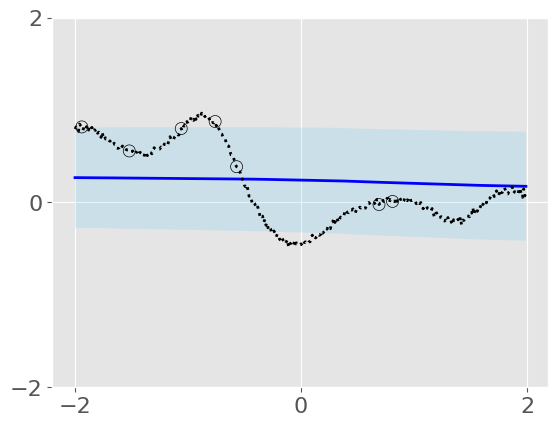

In [ ]:
TRAINING_ITERATIONS = 100000 #@param {type:"number"}
MAX_CONTEXT_POINTS = 50 #@param {type:"number"}
PLOT_AFTER = 10000 #@param {type:"number"}
HIDDEN_SIZE = 128 #@param {type:"number"}
MODEL_TYPE = 'NP' #@param ['NP','ANP']
ATTENTION_TYPE = 'uniform' #@param ['uniform','laplace','dot_product','multihead']
random_kernel_parameters = True #@param {type:"boolean"}

rng = jax.random.PRNGKey(0)

# Train dataset
rng, train_ds_rng = jax.random.split(rng)
dataset_train = GPCurvesReader(
    batch_size=16, max_num_context=MAX_CONTEXT_POINTS,
    random_kernel_parameters=random_kernel_parameters)

# Test dataset
rng, test_ds_rng = jax.random.split(rng)
dataset_test = GPCurvesReader(
    batch_size=1, max_num_context=MAX_CONTEXT_POINTS, testing=True,
    random_kernel_parameters=random_kernel_parameters)


# Sizes of the layers of the MLPs for the encoders and decoder
# The final output layer of the decoder outputs two values, one for the mean and
# one for the variance of the prediction at the target location
latent_encoder_output_sizes = [HIDDEN_SIZE]*4
num_latents = HIDDEN_SIZE
deterministic_encoder_output_sizes = [HIDDEN_SIZE]*4
decoder_output_sizes = [HIDDEN_SIZE]*2 + [2]
use_deterministic_path = True


# ANP with multihead attention
if MODEL_TYPE == 'ANP':
  attention = Attention(rep='mlp', output_sizes=[HIDDEN_SIZE]*2,
                         att_type=ATTENTION_TYPE)
# NP - equivalent to uniform attention
elif MODEL_TYPE == 'NP':
  attention = Attention(rep='identity', output_sizes=None, att_type='uniform')
else:
  raise NameError("MODEL_TYPE not among ['ANP,'NP']")

# Define the model
model = LatentModel(latent_encoder_output_sizes, num_latents,
                     decoder_output_sizes, use_deterministic_path,
                     deterministic_encoder_output_sizes, attention)

# Initialise the parameters using one sample batch
data_train, train_ds_rng = dataset_train.generate_curves(train_ds_rng)
rng, init_rng, sample_rng = jax.random.split(rng, 3)
params = model.init(init_rng, data_train.query, data_train.target_y,
                     rng=sample_rng)['params']

# Set up the optimizer
optimizer = optax.adam(1e-4)
opt_state = optimizer.init(params)


def loss_fn(params, rng, query, target_y):
  _, _, _, _, loss = model.apply({'params': params}, query, target_y, rng=rng)
  return loss


@jax.jit
def train_step(params, opt_state, rng, query, target_y):
  loss, grads = jax.value_and_grad(loss_fn)(params, rng, query, target_y)
  updates, opt_state = optimizer.update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state, loss


@jax.jit
def predict(params, rng, query):
  mu, sigma, _, _, _ = model.apply({'params': params}, query, rng=rng)
  return mu, sigma


# Train and plot
for it in range(TRAINING_ITERATIONS):
  data_train, train_ds_rng = dataset_train.generate_curves(train_ds_rng)
  rng, step_rng = jax.random.split(rng)
  params, opt_state, loss_value = train_step(
      params, opt_state, step_rng, data_train.query, data_train.target_y)

  # Plot the predictions in `PLOT_AFTER` intervals
  if it % PLOT_AFTER == 0:
    data_test, test_ds_rng = dataset_test.generate_curves(test_ds_rng)
    rng, pred_rng = jax.random.split(rng)
    pred_y, std_y = predict(params, pred_rng, data_test.query)

    (context_x, context_y), target_x = data_test.query
    target_y = data_test.target_y
    # print('Iteration: {}, loss: {}'.format(it, float(loss_value)))
    print(f'\nIteration: {it}/{TRAINING_ITERATIONS}, loss: {loss_value}\n')

    # Plot the prediction and the context
    plot_functions(target_x, target_y, context_x, context_y, pred_y, std_y)

### ANP training

Next, we train the ANP with multihead attention, using the same hyperparameter setting as NPs. Note that the predictions are now much more accurate for the observed context data.

In [ ]:
TRAINING_ITERATIONS = 100000 #@param {type:"number"}
MAX_CONTEXT_POINTS = 50 #@param {type:"number"}
PLOT_AFTER = 10000 #@param {type:"number"}
HIDDEN_SIZE = 128 #@param {type:"number"}
MODEL_TYPE = 'ANP' #@param ['NP','ANP']
ATTENTION_TYPE = 'multihead' #@param ['uniform','laplace','dot_product','multihead']
random_kernel_parameters = True #@param {type:"boolean"}

rng = jax.random.PRNGKey(0)

# Train dataset
rng, train_ds_rng = jax.random.split(rng)
dataset_train = GPCurvesReader(
    batch_size=16, max_num_context=MAX_CONTEXT_POINTS,
    random_kernel_parameters=random_kernel_parameters)

# Test dataset
rng, test_ds_rng = jax.random.split(rng)
dataset_test = GPCurvesReader(
    batch_size=1, max_num_context=MAX_CONTEXT_POINTS, testing=True,
    random_kernel_parameters=random_kernel_parameters)


# Sizes of the layers of the MLPs for the encoders and decoder
# The final output layer of the decoder outputs two values, one for the mean and
# one for the variance of the prediction at the target location
latent_encoder_output_sizes = [HIDDEN_SIZE]*4
num_latents = HIDDEN_SIZE
deterministic_encoder_output_sizes = [HIDDEN_SIZE]*4
decoder_output_sizes = [HIDDEN_SIZE]*2 + [2]
use_deterministic_path = True

# ANP with multihead attention
if MODEL_TYPE == 'ANP':
  attention = Attention(rep='mlp', output_sizes=[HIDDEN_SIZE]*2,
                         att_type='multihead')
# NP - equivalent to uniform attention
elif MODEL_TYPE == 'NP':
  attention = Attention(rep='identity', output_sizes=None, att_type='uniform')
else:
  raise NameError("MODEL_TYPE not among ['ANP,'NP']")

# Define the model
model = LatentModel(latent_encoder_output_sizes, num_latents,
                     decoder_output_sizes, use_deterministic_path,
                     deterministic_encoder_output_sizes, attention)

# Initialise the parameters using one sample batch
data_train, train_ds_rng = dataset_train.generate_curves(train_ds_rng)
rng, init_rng, sample_rng = jax.random.split(rng, 3)
params = model.init(init_rng, data_train.query, data_train.target_y,
                     rng=sample_rng)['params']

# Set up the optimizer
optimizer = optax.adam(1e-4)
opt_state = optimizer.init(params)


def loss_fn(params, rng, query, target_y):
  _, _, _, _, loss = model.apply({'params': params}, query, target_y, rng=rng)
  return loss


@jax.jit
def train_step(params, opt_state, rng, query, target_y):
  loss, grads = jax.value_and_grad(loss_fn)(params, rng, query, target_y)
  updates, opt_state = optimizer.update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state, loss


@jax.jit
def predict(params, rng, query):
  mu, sigma, _, _, _ = model.apply({'params': params}, query, rng=rng)
  return mu, sigma


# Train and plot
for it in range(TRAINING_ITERATIONS):
  data_train, train_ds_rng = dataset_train.generate_curves(train_ds_rng)
  rng, step_rng = jax.random.split(rng)
  params, opt_state, loss_value = train_step(
      params, opt_state, step_rng, data_train.query, data_train.target_y)

  # Plot the predictions in `PLOT_AFTER` intervals
  if it % PLOT_AFTER == 0:
    data_test, test_ds_rng = dataset_test.generate_curves(test_ds_rng)
    rng, pred_rng = jax.random.split(rng)
    pred_y, std_y = predict(params, pred_rng, data_test.query)

    (context_x, context_y), target_x = data_test.query
    target_y = data_test.target_y
    # print('Iteration: {}, loss: {}'.format(it, float(loss_value)))
    print(f'\nIteration: {it}/{TRAINING_ITERATIONS}, loss: {loss_value}\n')

    # Plot the prediction and the context
    plot_functions(target_x, target_y, context_x, context_y, pred_y, std_y)